In [2]:
## libraries to install ##
#!pip install seaborn pandas matplotlib numpy tabulate plotly

import os
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import numpy as np
from matplotlib.gridspec import GridSpec

from hbn.constants import Defaults  
from hbn.visualization import make_tables, visualize as vis, raw_scores
from hbn.visualization import utils as utils
from hbn.data import data_utils

import plotly.io as pio
pio.renderers.default='notebook'

%load_ext autoreload
%autoreload 2

import warnings
warnings.filterwarnings('ignore')

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
vis.plotting_style()

In [4]:
## visualize functions

# FUNCTIONS
def plot_bar(df, x='features', hue=None, plot_null=True, ax=None):

    # plot data
    data = df[df['data']=='data']
    fig = vis.barplot(
                data=data, 
                y='roc_auc_score', 
                x=x, 
                ylabel='ROC AUC', 
                hue=hue,
                xlabel=None, 
                ylim=[.4, 1.05],
                # join_lines=False,
                # markers="D",
                # scale=0.6,
                figsize=(6,4),
                ax=ax
                )

    # plot null model
    if plot_null:
        null = df[df['data']=='null'].groupby(x)['roc_auc_score'].mean().values
        plt.axhline(y=null.mean(), color='k', linestyle='--')

    return fig

def plot_line(df, x='readers', hue=None, plot_null=True, ax=None):
    fig = vis.pointplot(
                data=df[df['data']=='data'].sort_values(by=['features'], ascending=False), 
                y='roc_auc_score', 
                x=x, 
                ylabel='ROC AUC', 
                hue=hue,
                xlabel=None, 
                ylim=[.4, 1.05],
                # join_lines=False,
                # markers="D",
                # scale=0.6,
                figsize=(6,4),
                ax=ax
                )

    # plot null model
    if plot_null:
        null = df[df['data']=='null'].groupby(x)['roc_auc_score'].mean().values
        plt.axhline(y=null.mean(), color='k', linestyle='--')

    return fig

## Load Model Results

In [5]:

def get_missingness(summary, dx_col='DX_ADHD'):
    all_features = summary['features'].unique()

    out = {}
    for dx in summary[dx_col].unique():

        # get models that have been run
        check_models =summary[summary[dx_col]==dx]['features'].unique()

        models_to_run = list(set(all_features) - set(check_models))

        out.update({dx: models_to_run})
    
    return out


In [10]:
summary



""


In [11]:

# load data for all models run in `model_parent`
summary, features = data_utils.load_model_results(model='adhd_october_sex')

# remap diagnosis
summary['DX_ADHD'] = summary['DX_ADHD'] \
                    .fillna(summary['DX_Subtype_Name']) \
                    .map(utils.remap_dx())

# check missingness of models (which models need to be rerun)
out_models = get_missingness(summary, dx_col='DX_ADHD')
print(out_models)

# make new cols
summary['assessment'] = summary['features'].str.extract('(teacher|child|parent)')
summary['features'] = summary['features'].str.replace('teacher-', '').str.replace('child-', '').str.replace('parent-', '')

# add new cols for assessment
def map_assessment(x):
    data_dict = {
        'CBCL': ['externalizing', 'internalizing', 'anxious_depressed', 'rule_breaking',
                'aggressive_behavior', 'withdrawn_depressed', 'social_problems',
                'somatic_complaints', 'thought_problems', 'attention_problems'],
        'C3SR': ['defiance_aggression', 'family_relations', 'hyperactive_impulsivity', 'inattention',
                'learning_problems', 'negative_impression', 'positive_impression'],
        'suicidality': ['suicidality'],
        'demos': ['demos-excl-sex'],
        'SWAN': ['swan_hyperactive', 'swan_inattention'],
    }
    for k,v in data_dict.items():
        if x in v:
            return k

summary['measure'] = summary['features'].apply(lambda x: map_assessment(x))


{'ADHD (all comorbid.)': [], 'ADHD (no comorbid.)': [], 'Other diagnoses': [], 'No Diagnosis': [], 'ADHD (Combined Type)': [], 'ADHD (Inattentive Type)': [], 'ADHD (Hyperactive Type)': []}


In [12]:
## FUNCTIONS

def fig1A(ax, 
          summary, 
          subplot='A', 
          feature='selected_all', 
          hue=None, 
          Race=['all'],  
          target='DX', 
          target_cols=['ADHD (all comorbid.)', 'ADHD (no comorbid.)'],
          features=None, 
          measure=None,
          assessment=['child', 'parent', 'teacher'], 
          sex=['male_female']
          ):
        
        # grab features if measure is given
        if (measure is not None) and (features is None):
            summary = summary[summary['measure'].isin(measure)]
            features = summary['features'].unique()

        default_params = {'Sex': sex,
                        'feature_threshold': [f'{feature}'],
                        target: target_cols,
                        'development': ['all'],
                        'data': ['data'],
                        'features': features,
                        'assessment': assessment,
                        'Race': Race,
                        }

        # filter dataframe
        df_filter = utils.filter_train(summary, columns=list(default_params.keys()), values=list(default_params.values()))

        # plot data
        vis.barplot(data=df_filter.sort_values(by='assessment'), 
                    x='features', ax=ax, subplot=subplot, hue=hue,
                    )

        default_params.update({'data': ['null']})

        # filter dataframe to just 1 feature
        df_filter = utils.filter_train(summary, columns=list(default_params.keys()), values=list(default_params.values()))

        # plot reading model
        ax.axhline(y=df_filter['roc_auc_score'].mean(), color='k', linestyle='--')


def fig1B(ax, summary, subplot='B', feature='selected_all', 
          sex=['male_female'], target='DX', Race=['all'], development=['5-7', '8-10', '11-13', '14-16', '17-21'],
          features=['child-internalizing', 'parent-internalizing', 'teacher-internalizing']):

        default_params = {'Sex': sex,
                        'feature_threshold': [f'{feature}'],
                        target: ['ADHD (all comorbid.)'],
                        'development': development,
                        'data': ['data'],
                        'features': features,
                        'Race': Race,
                        }

        # filter dataframe
        df_filter = utils.filter_train(summary, columns=list(default_params.keys()), values=list(default_params.values()))

        # get new col
        df_filter['assessment'] = df_filter['features'].str.extract('(teacher|child|parent)')

        vis.pointplot(data=df_filter.sort_values(by=['development']), 
                        x='development', 
                        hue='assessment', 
                        order=development,
                        ax=ax, 
                        ylim=[0.4, 1.05],
                        subplot=subplot
                        )

        default_params.update({'data': ['null']})

        # filter dataframe to just 1 feature
        df_filter = utils.filter_train(summary, columns=list(default_params.keys()), values=list(default_params.values()))

        # plot reading model
        ax.axhline(y=df_filter['roc_auc_score'].mean(), color='k', linestyle='--')

def fig1C(ax, summary, subplot='C', feature='selected_all', Race=['all'],
        features=['child-internalizing', 'parent-internalizing', 'teacher-internalizing'], sex=['male', 'female'], target='DX'):

        default_params = {'Sex': sex,
                        'feature_threshold': [f'{feature}',],
                        target: ['ADHD (all comorbid.)'],
                        'development': ['all'],
                        'data': ['data'],
                        'features': features,
                        'Race': Race,
                        }

        # filter dataframe
        df_filter = utils.filter_train(summary, columns=list(default_params.keys()), values=list(default_params.values()))
        df_filter['assessment'] = df_filter['features'].str.extract('(teacher|child|parent)')

        # plot data
        vis.barplot(data=df_filter, x='assessment', hue='Sex', ax=ax, subplot=subplot)

        default_params.update({'data': ['null']})

        # filter dataframe to just 1 feature
        df_filter = utils.filter_train(summary, columns=list(default_params.keys()), values=list(default_params.values()))

        # plot reading model
        ax.axhline(y=df_filter['roc_auc_score'].mean(), color='k', linestyle='--')


def fig1D(ax, summary, subplot='D', feature='selected_all', Race=['all'], development=['5-7', '8-10', '11-13', '14-16', '17-21'],
          features=['parent-internalizing'], sex=['male', 'female'], target='DX'):

        default_params = {'Sex': sex,
                        'development': development,
                        'feature_threshold': [f'{feature}'],
                        target: ['ADHD (all comorbid.)', 'ADHD (no comorbid.)'],
                        'data': ['data'],
                        'features': features,
                        'Race': Race,
                        }

        # filter dataframe
        df_filter = utils.filter_train(summary, columns=list(default_params.keys()), values=list(default_params.values()))

        vis.pointplot(data=df_filter, x='development', 
                      order=development,
                        hue='Sex', ax=ax, subplot=subplot, legend=True,)

        default_params.update({'data': ['null']})

        # filter dataframe to just 1 feature
        df_filter = utils.filter_train(summary, columns=list(default_params.keys()), values=list(default_params.values()))

        # plot reading model
        ax.axhline(y=df_filter['roc_auc_score'].mean(), color='k', linestyle='--')

## Classifying Sex

In [16]:
summary['DX_Subtype_Name'].unique()

array([nan, 'ADHD-Combined Type', 'ADHD-Inattentive Type',
       'ADHD-Hyperactive/Impulsive Type'], dtype=object)

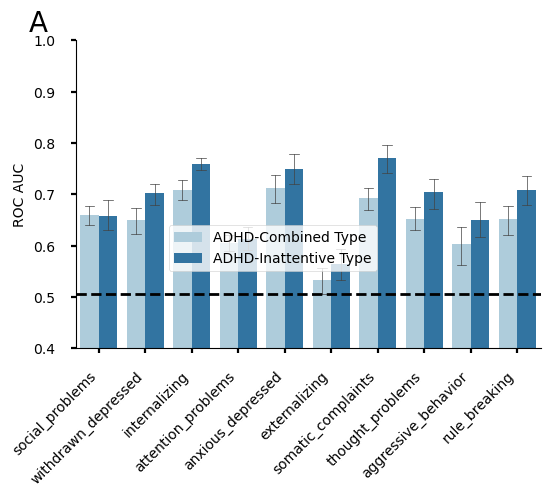

In [18]:
# # plot
vis.plotting_style()
fig = plt.figure(figsize=(6,4))
gs = GridSpec(1, 2, figure=fig)

# 1A
ax = fig.add_subplot(gs[0, :])

fig1A(ax, summary, sex=['male_female'], 
      target='DX_Subtype_Name', 
      target_cols=['ADHD-Combined Type', 'ADHD-Inattentive Type'],
      hue='DX_Subtype_Name', 
      measure=['CBCL'],
      assessment=['child']
      )


### Supp 4.

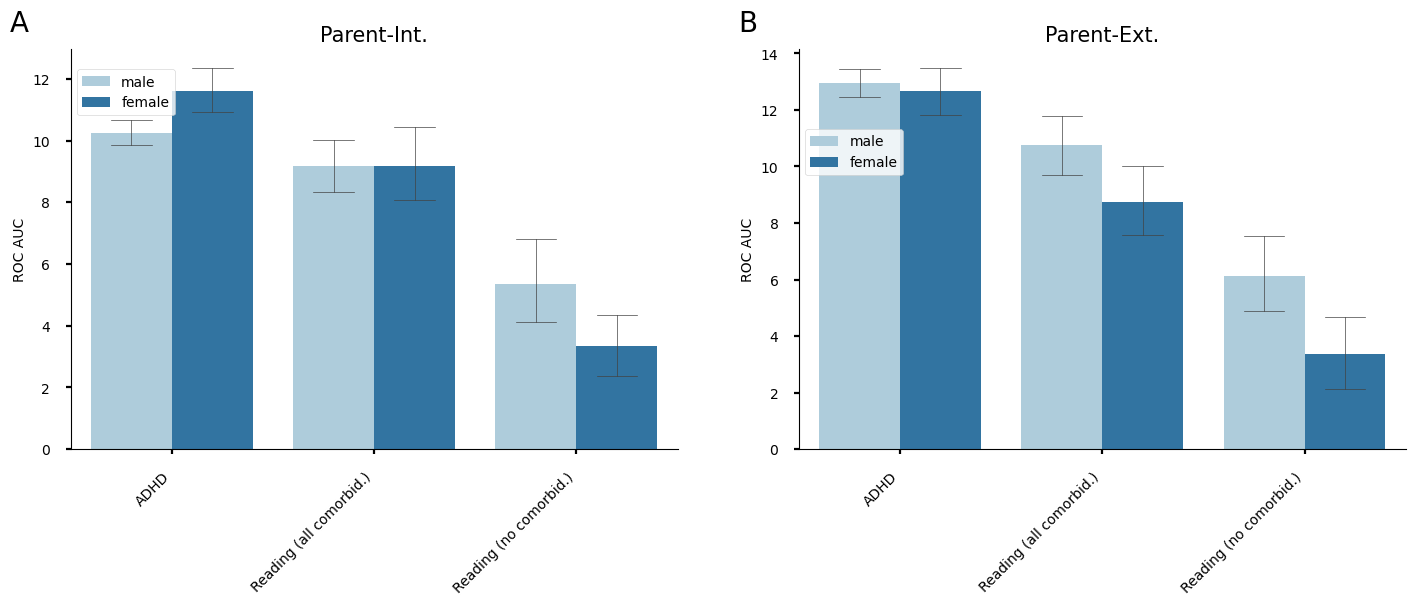

In [191]:
df = raw_scores.load_parent_child_teacher(key=['Int', 'Ext'], dx_to_include=['Reading (all comorbid.)','Reading (no comorbid.)', 'ADHD'])

# # plot
vis.plotting_style()
fig = plt.figure(figsize=(2,2))
gs = GridSpec(1, 2, figure=fig)

plot_dict = {'A': ['CBCL,CBCL_Int', (0,0), True, 'Parent-Int.', (.01, .95)],
            'B': ['CBCL,CBCL_Ext', (0,1), True, 'Parent-Ext.', (.01,.8)],
            }

for i, (key, value) in enumerate(plot_dict.items()):
    ax = fig.add_subplot(gs[plot_dict[key][1]])
    vis.barplot(x='DX_Reading', y=value[0], hue='Sex', 
                    data=df, ax=ax, ylim=None, subplot=key, 
                    bbox_to_anchor=value[4],
                    title=value[3], legend=value[2])
    
fig.subplots_adjust(left=0.125, bottom=0.001, right=6.8, top=2.0, wspace=.2, hspace=.3)
fig.savefig(os.path.join(Defaults.FIG_DIR, f'Supp4.png'), bbox_inches='tight')


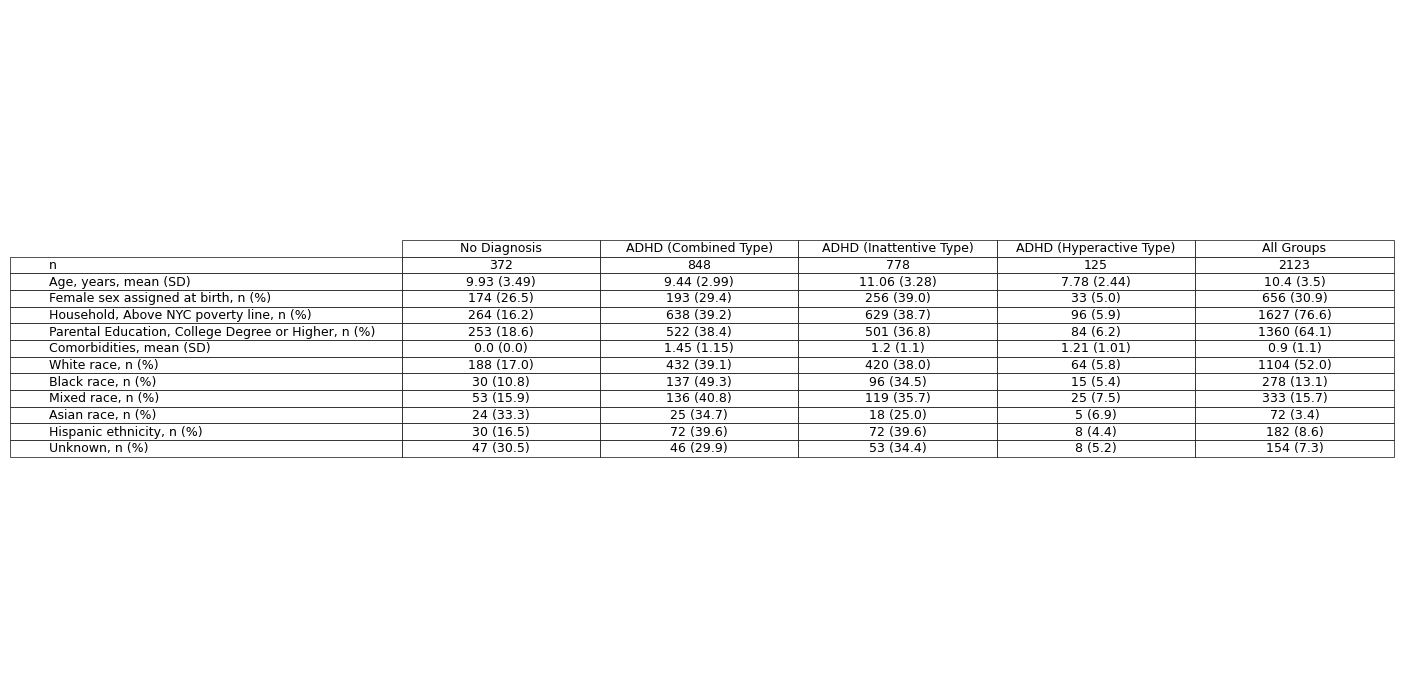

In [53]:
from hbn.visualization.make_tables import make_table_1, make_table_2

make_table_1(split='DX_ADHD', 
             split_vals=['No Diagnosis', 'ADHD (all comorbid.)', 'ADHD (no comorbid.)', 'Other diagnoses']
             )

make_table_1(split='DX_Subtype_Name', 
            split_vals=['No Diagnosis', 'ADHD (Combined Type)', 'ADHD (Inattentive Type)', 'ADHD (Hyperactive Type)']
            )
